# **Setting up enviroment**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install "chronos-forecasting>=2.0.0" accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 112.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.9 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
!pip install autogluon.timeseries autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 19.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter co

In [ ]:
!pip install sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 13.2 MB/s eta 0:00:00


In [ ]:
import autogluon.timeseries
print(autogluon.timeseries.__version__)

1.5.0


# **Loading and processing data**

In [ ]:
import pandas as pd
from datasets import load_dataset
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

ds = load_dataset("codenhenhe/volta-solar-daily-v1")
train_df = ds["train"].to_pandas()
val_df   = ds["validation"].to_pandas()
test_df   = ds["test"].to_pandas()

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/83.9M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/11.2M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/23.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1278500 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/182500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/365500 [00:00<?, ? examples/s]

In [ ]:
ds

DatasetDict({
    train: Dataset({
        features: ['solar_ref_id', 'date', 'lat', 'long', 'ALLSKY_SFC_SW_DWN', 'T2M', 'WS2M', 'RH2M', 'T_cell', 'temp_factor', 'solar_gen_kwh', 'day_of_year', 'month', '__index_level_0__'],
        num_rows: 1278500
    })
    validation: Dataset({
        features: ['solar_ref_id', 'date', 'lat', 'long', 'ALLSKY_SFC_SW_DWN', 'T2M', 'WS2M', 'RH2M', 'T_cell', 'temp_factor', 'solar_gen_kwh', 'day_of_year', 'month', '__index_level_0__'],
        num_rows: 182500
    })
    test: Dataset({
        features: ['solar_ref_id', 'date', 'lat', 'long', 'ALLSKY_SFC_SW_DWN', 'T2M', 'WS2M', 'RH2M', 'T_cell', 'temp_factor', 'solar_gen_kwh', 'day_of_year', 'month', '__index_level_0__'],
        num_rows: 365500
    })
})

In [ ]:
val_df

,solar_ref_id,date,lat,long,ALLSKY_SFC_SW_DWN,T2M,WS2M,RH2M,T_cell,temp_factor,solar_gen_kwh,day_of_year,month,__index_level_0__
0,AUS_SOLAR_REF_000,2023-01-01,-27.832,114.852,9.1733,25.61,5.55,45.88,48.54325,0.917599,44.443911,1,1,2557
1,AUS_SOLAR_REF_000,2023-01-02,-27.832,114.852,8.5126,32.21,6.23,25.99,53.49150,0.900280,40.464449,2,1,2558
2,AUS_SOLAR_REF_000,2023-01-03,-27.832,114.852,8.4670,34.70,6.61,17.99,55.86750,0.891964,39.875917,3,1,2559
3,AUS_SOLAR_REF_000,2023-01-04,-27.832,114.852,8.3974,35.58,5.41,15.56,56.57350,0.889493,39.438571,4,1,2560
4,AUS_SOLAR_REF_000,2023-01-05,-27.832,114.852,8.5397,35.16,4.59,17.12,56.50925,0.889718,40.117026,5,1,2561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182495,AUS_SOLAR_REF_499,2023-12-27,-33.865,147.461,7.2103,20.54,1.51,65.12,38.56575,0.952520,36.262797,361,12,1825764
182496,AUS_SOLAR_REF_499,2023-12-28,-33.865,147.461,8.2466,24.75,3.24,53.63,45.36650,0.928717,40.438251,362,12,1825765
182497,AUS_SOLAR_REF_499,2023-12-29,-33.865,147.461,3.1534,22.16,2.31,63.87,30.04350,0.982348,16.356043,363,12,1825766
182498,AUS_SOLAR_REF_499,2023-12-30,-33.865,147.461,9.3598,21.01,3.01,53.42,44.40950,0.932067,46.062500,364,12,1825767


In [ ]:
def prepare_data(df):
    # item_id: solar_ref_id
    # timestamp: date
    # target: solar_gen_kwh
    df = df.rename(columns={
        "solar_ref_id": "item_id",
        "date": "timestamp",
        "solar_gen_kwh": "target"
    })

    # Chuyển timestamp sang định dạng datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Loại bỏ cột index thừa nếu có để tránh nhiễu
    if "__index_level_0__" in df.columns:
        df = df.drop(columns=["__index_level_0__", "lat", "long", "temp_factor", "T_cell"])

    # Tạo TimeSeriesDataFrame
    return TimeSeriesDataFrame(df)

train_data_raw = prepare_data(train_df)
val_data_raw = prepare_data(val_df)

tuning_data = pd.concat([train_data_raw, val_data_raw]).sort_values(["item_id", "timestamp"])
tuning_data = TimeSeriesDataFrame(tuning_data)

In [ ]:
train_data_raw

ALLSKY_SFC_SW_DWN    T2M  WS2M   RH2M  \
item_id           timestamp                                           
AUS_SOLAR_REF_000 2016-01-01             8.9544  31.15  4.20  40.78   
                  2016-01-02             8.5466  26.56  4.61  53.99   
                  2016-01-03             8.2236  26.15  2.78  55.57   
                  2016-01-04             5.6350  25.23  3.16  58.72   
                  2016-01-05             5.3940  24.70  3.66  59.91   
...                                         ...    ...   ...    ...   
AUS_SOLAR_REF_499 2022-12-27             9.3326  26.98  2.85  41.82   
                  2022-12-28             9.2441  26.85  3.63  45.91   
                  2022-12-29             2.9136  24.17  1.60  66.30   
                  2022-12-30             8.2678  23.28  1.97  69.98   
                  2022-12-31             7.7484  24.00  2.23  61.61   

                                 target  day_of_year  month  
item_id           timestamp                                  
AUS_SOLAR_REF_000 2016-01-01  42.557171            1      1  
                  2016-01-02  41.505010            2      1  
                  2016-01-03  40.121445            3      1  
                  2016-01-04  28.261850            4      1  
                  2016-01-05  27.166024            5      1  
...                                 ...          ...    ...  
AUS_SOLAR_REF_499 2022-12-27  44.910744          361     12  
                  2022-12-28  44.544864          362     12  
                  2022-12-29  15.036303          363     12  
                  2022-12-30  40.758710          364     12  
                  2022-12-31  38.281001          365     12  

[1278500 rows x 7 columns]

In [ ]:
tuning_data

ALLSKY_SFC_SW_DWN    T2M  WS2M   RH2M  \
item_id           timestamp                                           
AUS_SOLAR_REF_000 2016-01-01             8.9544  31.15  4.20  40.78   
                  2016-01-02             8.5466  26.56  4.61  53.99   
                  2016-01-03             8.2236  26.15  2.78  55.57   
                  2016-01-04             5.6350  25.23  3.16  58.72   
                  2016-01-05             5.3940  24.70  3.66  59.91   
...                                         ...    ...   ...    ...   
AUS_SOLAR_REF_499 2023-12-27             7.2103  20.54  1.51  65.12   
                  2023-12-28             8.2466  24.75  3.24  53.63   
                  2023-12-29             3.1534  22.16  2.31  63.87   
                  2023-12-30             9.3598  21.01  3.01  53.42   
                  2023-12-31             8.7427  22.94  1.98  52.82   

                                 target  day_of_year  month  
item_id           timestamp                                  
AUS_SOLAR_REF_000 2016-01-01  42.557171            1      1  
                  2016-01-02  41.505010            2      1  
                  2016-01-03  40.121445            3      1  
                  2016-01-04  28.261850            4      1  
                  2016-01-05  27.166024            5      1  
...                                 ...          ...    ...  
AUS_SOLAR_REF_499 2023-12-27  36.262797          361     12  
                  2023-12-28  40.438251          362     12  
                  2023-12-29  16.356043          363     12  
                  2023-12-30  46.062500          364     12  
                  2023-12-31  42.962992          365     12  

[1461000 rows x 7 columns]

# **Weather vars**

## **Finetuning**

In [ ]:
prediction_length = 365

known_covariate_names = ['day_of_year', 'month', 'ALLSKY_SFC_SW_DWN', 'T2M', 'WS2M', 'RH2M']

predictor = TimeSeriesPredictor(
    target='target',
    prediction_length=prediction_length,
    path="/content/drive/MyDrive/TT/finetuned_model/chronos_2/weather_vars_6_1e_6_300_8",
    eval_metric="MSE",
    known_covariates_names=known_covariate_names
)

In [ ]:
hyperparameters = {
    "Chronos2": [
        # 1. Bản Zero-shot (Chỉ dự báo, không học thêm)
        {"ag_args": {"name_suffix": "_ZeroShot"}},

        # 2. Bản Fine-tuned (Có học thêm với LoRA)
        {
            "fine_tune": True,
            "fine_tune_mode": "lora",
            "fine_tune_lr": 1e-6,
            "fine_tune_steps": 300,
            "fine_tune_batch_size": 8,
            "fine_tune_context_length": 730,
            "eval_during_fine_tune": True,
            "fine_tune_lora_config": {"r": 32, "lora_alpha": 64},
            "ag_args": {"name_suffix": "_FineTuned"}
        },
    ]
}

In [ ]:
predictor.fit(
    train_data=train_data_raw,
    tuning_data=tuning_data,
    hyperparameters=hyperparameters,
    time_limit=3600,
    enable_ensemble=False,
)

Beginning AutoGluon training... Time limit = 3600s
AutoGluon will save models to '/content/drive/MyDrive/TT/finetuned_model/chronos_2/weather_vars_6_1e_6_300_8'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.55/14.56 GB
Total GPU Memory:   Free: 14.55 GB, Allocated: 0.02 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       8.75 GB / 12.67 GB (69.1%)
Disk Space Avail:   3.38 GB / 15.00 GB (22.5%)
	We recommend a minimum available disk space of 10 GB, and large datasets may require more.

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': MSE,
 'hyperparameters': {'Chronos2': [{'ag_args': {'name_suffix': '_ZeroShot'}},
                                  {'ag_args': {'name_suffix': '_FineTuned

## **Evaluation**

In [ ]:
test_data_raw = prepare_data(test_df)

test_data_combined = pd.concat([train_data_raw, val_data_raw, test_data_raw])
test_data_combined = TimeSeriesDataFrame(test_data_combined).sort_values(["item_id", "timestamp"])

test_data_combined

ALLSKY_SFC_SW_DWN    T2M  WS2M   RH2M  \
item_id           timestamp                                           
AUS_SOLAR_REF_000 2016-01-01             8.9544  31.15  4.20  40.78   
                  2016-01-02             8.5466  26.56  4.61  53.99   
                  2016-01-03             8.2236  26.15  2.78  55.57   
                  2016-01-04             5.6350  25.23  3.16  58.72   
                  2016-01-05             5.3940  24.70  3.66  59.91   
...                                         ...    ...   ...    ...   
AUS_SOLAR_REF_499 2025-12-27             9.6631  19.30  2.33  41.20   
                  2025-12-28             8.7079  21.64  3.20  37.60   
                  2025-12-29             9.6110  24.35  1.99  34.56   
                  2025-12-30             8.8459  27.43  1.90  27.50   
                  2025-12-31             8.4458  28.13  3.41  25.73   

                                 target  day_of_year  month  
item_id           timestamp                                  
AUS_SOLAR_REF_000 2016-01-01  42.557171            1      1  
                  2016-01-02  41.505010            2      1  
                  2016-01-03  40.121445            3      1  
                  2016-01-04  28.261850            4      1  
                  2016-01-05  27.166024            5      1  
...                                 ...          ...    ...  
AUS_SOLAR_REF_499 2025-12-27  47.725092          361     12  
                  2025-12-28  43.015178          362     12  
                  2025-12-29  46.593972          363     12  
                  2025-12-30  42.693967          364     12  
                  2025-12-31  40.809782          365     12  

[1826500 rows x 7 columns]

In [ ]:
# model_path = '/content/drive/MyDrive/TT/finetuned_model/autogluon_chronos_lora_solar/'
model_path = '/content/drive/MyDrive/TT/finetuned_model/chronos_2/weather_vars_6_1e_6_300_8/'
# model_path = '/content/drive/MyDrive/TT/finetuned_model/chronos_2/weather_vars/'


# Load model
predictor_loaded = TimeSeriesPredictor.load(model_path)

Loading predictor from path /content/drive/MyDrive/TT/finetuned_model/chronos_2/weather_vars_6_1e_6_300_8


In [ ]:
leaderboard = predictor_loaded.leaderboard(test_data_combined)
print(leaderboard)

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


                model  score_test  score_val  pred_time_test  pred_time_val  \
0   Chronos2_ZeroShot  -12.778874 -12.909413       81.785062      64.659334   
1  Chronos2_FineTuned  -13.847706 -15.083832       84.774605      74.149402   

   fit_time_marginal  fit_order  
0           0.610633          1  
1         442.519147          2  


In [ ]:
CONTEXT_LENGTH = 730
PREDICTION_LENGTH = 365
# Chronos2_ZeroShot

# 2025
context_2025 = test_data_combined.query("timestamp < '2025-01-01'").groupby('item_id').tail(CONTEXT_LENGTH)
known_2025 = test_data_combined.query("timestamp >= '2025-01-01' and timestamp < '2026-01-01'")[predictor_loaded.known_covariates_names]

forecast_2025 = predictor_loaded.predict(context_2025, known_covariates=known_2025, model="Chronos2_ZeroShot")

# 2024
context_2024 = test_data_combined.query("timestamp < '2024-01-01'").groupby('item_id').tail(CONTEXT_LENGTH)
known_2024 = test_data_combined.query("timestamp >= '2024-01-01' and timestamp < '2025-01-01'")[predictor_loaded.known_covariates_names]

forecast_2024 = predictor_loaded.predict(context_2024, known_covariates=known_2024, model="Chronos2_ZeroShot")

# merge results
all_forecasts = pd.concat([forecast_2024, forecast_2025])

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error
import numpy as np

def calculate_metrics(y_true_df, y_pred_df, label):
    # Lấy các index chung giữa thực tế và dự báo
    y_true = y_true_df.loc[common_idx, 'target']
    y_pred = y_pred_df.loc[common_idx, '0.5']

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    smape = mean_absolute_percentage_error(y_true, y_pred, symmetric=True) * 100

    print(f"--- Chỉ số cho {label} ---")
    print(f"MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | sMAPE: {smape:.2f}%")

    # return {
    #     "mse": mse,
    #     "rmse": rmse,
    #     "mae": mae,
    #     "smape": smape
    # }

metrics_2024 = calculate_metrics(test_data_combined, forecast_2024, "Năm 2024")
metrics_2025 = calculate_metrics(test_data_combined, forecast_2025, "Năm 2025")

--- Chỉ số cho Năm 2024 ---
MSE: 13.0110 | RMSE: 3.6071 | MAE: 2.5782 | MAPE: 12.80%
--- Chỉ số cho Năm 2025 ---
MSE: 13.4913 | RMSE: 3.6731 | MAE: 2.6233 | MAPE: 13.00%


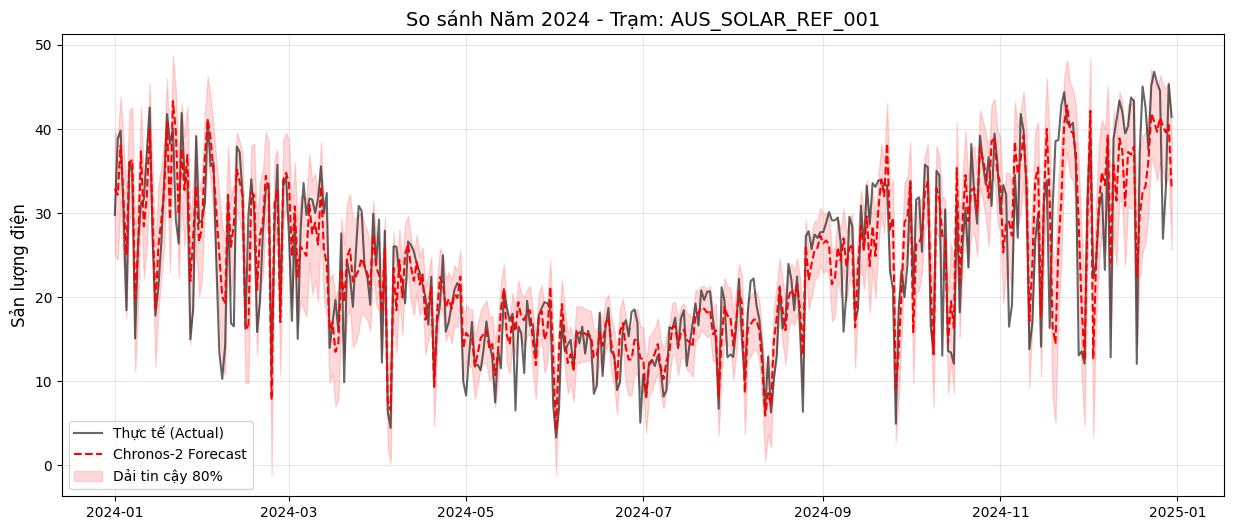

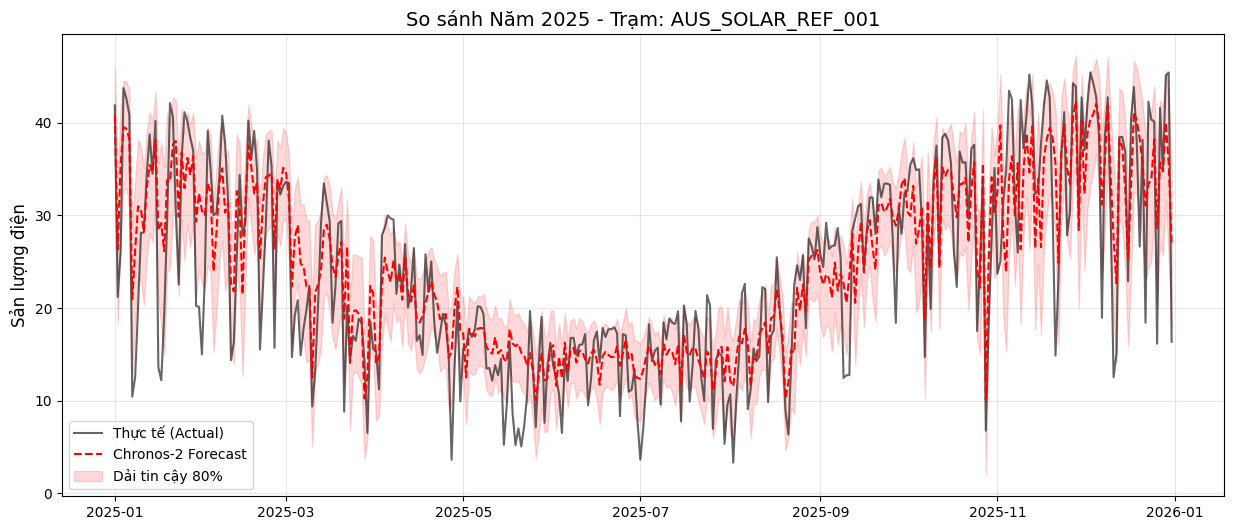

In [ ]:
import matplotlib.pyplot as plt

def plot_yearly_comparison(item_id, actual_df, forecast_df, title):
    plt.figure(figsize=(15, 6))

    common_idx = actual_df.index.intersection(forecast_df.index)
    y_true = actual_df.loc[common_idx]
    y_pred = forecast_df.loc[common_idx]

    # draw actual
    plt.plot(y_true.index.get_level_values('timestamp'), y_true['target'],
             label='Thực tế (Actual)', color='black', alpha=0.6, linewidth=1.5)

    # draw predict (Median - 0.5)
    plt.plot(y_pred.index.get_level_values('timestamp'), y_pred['0.5'],
             label='Chronos-2 Forecast', color='red', linestyle='--', linewidth=1.5)

    # draw reliability 80% (between quantile 0.1 and 0.9)
    plt.fill_between(y_pred.index.get_level_values('timestamp'),
                     y_pred['0.1'], y_pred['0.9'],
                     color='red', alpha=0.15, label='Dải tin cậy 80%')

    plt.title(f"{title} - Trạm: {item_id}", fontsize=14)
    plt.ylabel("Sản lượng điện", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# choose 1 station for eval
target_item = "AUS_SOLAR_REF_001"

plot_yearly_comparison(target_item, test_data_combined.loc[target_item],
                       forecast_2024.loc[target_item], "So sánh Năm 2024")

plot_yearly_comparison(target_item, test_data_combined.loc[target_item],
                       forecast_2025.loc[target_item], "So sánh Năm 2025")

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

def calculate_qa_metrics(y_true, y_pred, label="Model"):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    smape = mean_absolute_percentage_error(y_true, y_pred, symmetric=True) * 100
    r2 = r2_score(y_true, y_pred)
    return {"Model": label, "MAE": mae, "MSE": mse, "RMSE": rmse, "sMAPE(%)": smape, "R2": r2}

# Actual
common_idx = test_data_combined.index.intersection(all_forecasts.index)
y_true = test_data_combined.loc[common_idx, 'target']

# Prediction
y_pred_ai = all_forecasts.loc[common_idx, '0.5']

# Baseline: Seasonal Naive
y_baseline = test_data_combined.shift(365).loc[common_idx, 'target'].bfill()

# Compare
metrics_ai = calculate_qa_metrics(y_true, y_pred_ai, "Chronos2-Volta AI")
metrics_base = calculate_qa_metrics(y_true, y_baseline, "Seasonal Naive (Baseline)")

# Print result
df_comparison = pd.DataFrame([metrics_ai, metrics_base])
print("BẢNG SO SÁNH CHỈ SỐ CHẤT LƯỢNG")
print(df_comparison.to_string(index=False))

=== BẢNG SO SÁNH CHỈ SỐ CHẤT LƯỢNG (Step 9) ===
                    Model      MAE     RMSE   MAPE(%)       R2
        Chronos2-Volta AI 2.600748 3.640213 12.897249 0.870021
Seasonal Naive (Baseline) 6.080324 8.468857 29.693408 0.296490


In [ ]:
def mean_pinball_loss(y_true, y_pred, quantile):
    delta = y_true - y_pred
    return np.mean(np.maximum(quantile * delta, (quantile - 1) * delta))

# Check if the bands are reliable
q10_loss = mean_pinball_loss(y_true, all_forecasts.loc[common_idx, '0.1'], 0.1)
q90_loss = mean_pinball_loss(y_true, all_forecasts.loc[common_idx, '0.9'], 0.9)

print(f"\nProbabilistic Metrics:")
print(f"Quantile Loss (0.1): {q10_loss:.4f}")
print(f"Quantile Loss (0.9): {q90_loss:.4f}")
print(f"Average Quantile Loss: {(q10_loss + q90_loss)/2:.4f}")


Probabilistic Metrics:
Quantile Loss (0.1): 0.6660
Quantile Loss (0.9): 0.5201
Average Quantile Loss: 0.5930


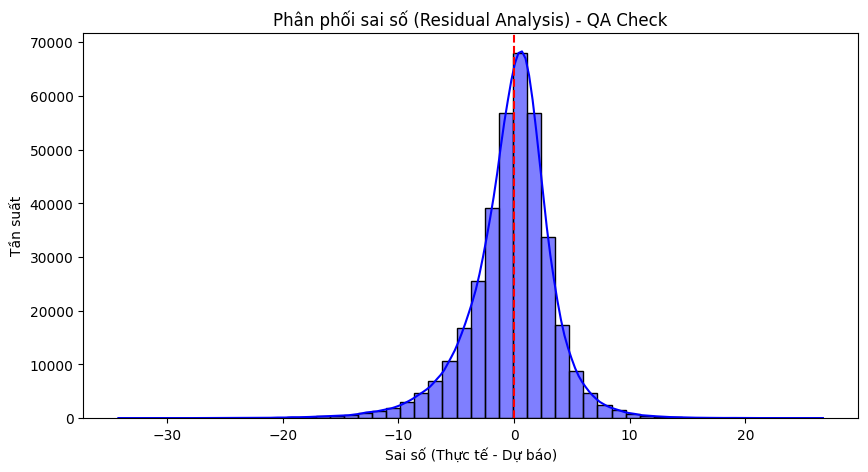

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_true - y_pred_ai
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, bins=50, color='blue')
plt.axvline(0, color='red', linestyle='--')
plt.title("Phân phối sai số (Residual Analysis) - QA Check")
plt.xlabel("Sai số (Thực tế - Dự báo)")
plt.ylabel("Tần suất")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error

# --- 1. Hàm tính toán chỉ số tổng hợp ---
def get_full_metrics(y_true, forecast_df, label, period):
    # Lấy index chung
    common_idx = y_true.index.intersection(forecast_df.index)
    y_t = y_true.loc[common_idx]
    y_p = forecast_df.loc[common_idx, '0.5']

    # Deterministic Metrics
    mae = mean_absolute_error(y_t, y_p)
    mse = mean_squared_error(y_t, y_p)
    rmse = np.sqrt(mse)
    smape = mean_absolute_percentage_error(y_t, y_p, symmetric=True) * 100
    r2 = r2_score(y_t, y_p)

    # Probabilistic Metrics (Pinball Loss)
    def pinball_loss(target, pred, q):
        return np.mean(np.maximum(q * (target - pred), (q - 1) * (target - pred)))

    q10 = pinball_loss(y_t, forecast_df.loc[common_idx, '0.1'], 0.1)
    q90 = pinball_loss(y_t, forecast_df.loc[common_idx, '0.9'], 0.9)
    avg_q = (q10 + q90) / 2

    return {
        "Model": label,
        "Period": period,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "sMAPE(%)": smape,
        "R2": r2,
        "Q_0.1": q10,
        "Q_0.9": q90,
        "Avg_Q_Loss": avg_q
    }

# --- 2. Chạy dự báo cho cả 2 Model ---
models_to_test = {
    "Chronos Zero-Shot": "Chronos2_ZeroShot",
    "Chronos Fine-Tuned": "Chronos2_FineTuned" # Thay tên model fine-tune của bạn ở đây
}

results_list = []
all_forecast_storage = {}

for label, model_name in models_to_test.items():
    print(f"Processing {label}...")

    # Dự báo 2024
    f_2024 = predictor_loaded.predict(context_2024, known_covariates=known_2024, model=model_name)
    # Dự báo 2025
    f_2025 = predictor_loaded.predict(context_2025, known_covariates=known_2025, model=model_name)
    # Tổng hợp 2 năm
    f_overall = pd.concat([f_2024, f_2025])
    all_forecast_storage[label] = f_overall

    # Tính toán cho từng năm và Overall
    results_list.append(get_full_metrics(test_data_combined['target'], f_2024, label, "2024"))
    results_list.append(get_full_metrics(test_data_combined['target'], f_2025, label, "2025"))
    results_list.append(get_full_metrics(test_data_combined['target'], f_overall, label, "Overall"))

# --- 3. Xuất kết quả định dạng Báo cáo ---
df_final = pd.DataFrame(results_list)

# Bảng 1: Point Forecast Accuracy (MAE, MSE, RMSE, sMAPE, R2)
table_1 = df_final[["Model", "Period", "MAE", "MSE", "RMSE", "sMAPE(%)", "R2"]]
print("\n=== TABLE 1: POINT FORECAST ACCURACY ===")
print(table_1.to_string(index=False))

# Bảng 2: Probabilistic Metrics (Quantile Loss)
table_2 = df_final[["Model", "Period", "Q_0.1", "Q_0.9", "Avg_Q_Loss"]]
print("\n=== TABLE 2: PROBABILISTIC RELIABILITY ===")
print(table_2.to_string(index=False))

Processing Chronos Zero-Shot...
Processing Chronos Fine-Tuned...

=== TABLE 1: POINT FORECAST ACCURACY ===
             Model  Period      MAE       MSE     RMSE  sMAPE(%)       R2
 Chronos Zero-Shot    2024 2.388127 11.104081 3.332279 10.847282 0.889259
 Chronos Zero-Shot    2025 2.485143 12.197572 3.492502 11.135355 0.882219
 Chronos Zero-Shot Overall 2.436635 11.650827 3.413331 10.991318 0.885718
Chronos Fine-Tuned    2024 2.374061 11.042445 3.323017 10.768443 0.889873
Chronos Fine-Tuned    2025 2.468275 12.076611 3.475142 11.053124 0.883387
Chronos Fine-Tuned Overall 2.421168 11.559528 3.399931 10.910783 0.886614

=== TABLE 2: PROBABILISTIC RELIABILITY ===
             Model  Period    Q_0.1    Q_0.9  Avg_Q_Loss
 Chronos Zero-Shot    2024 0.598676 0.501873    0.550275
 Chronos Zero-Shot    2025 0.631314 0.508668    0.569991
 Chronos Zero-Shot Overall 0.614995 0.505271    0.560133
Chronos Fine-Tuned    2024 0.601763 0.500016    0.550889
Chronos Fine-Tuned    2025 0.635956 0.506356  

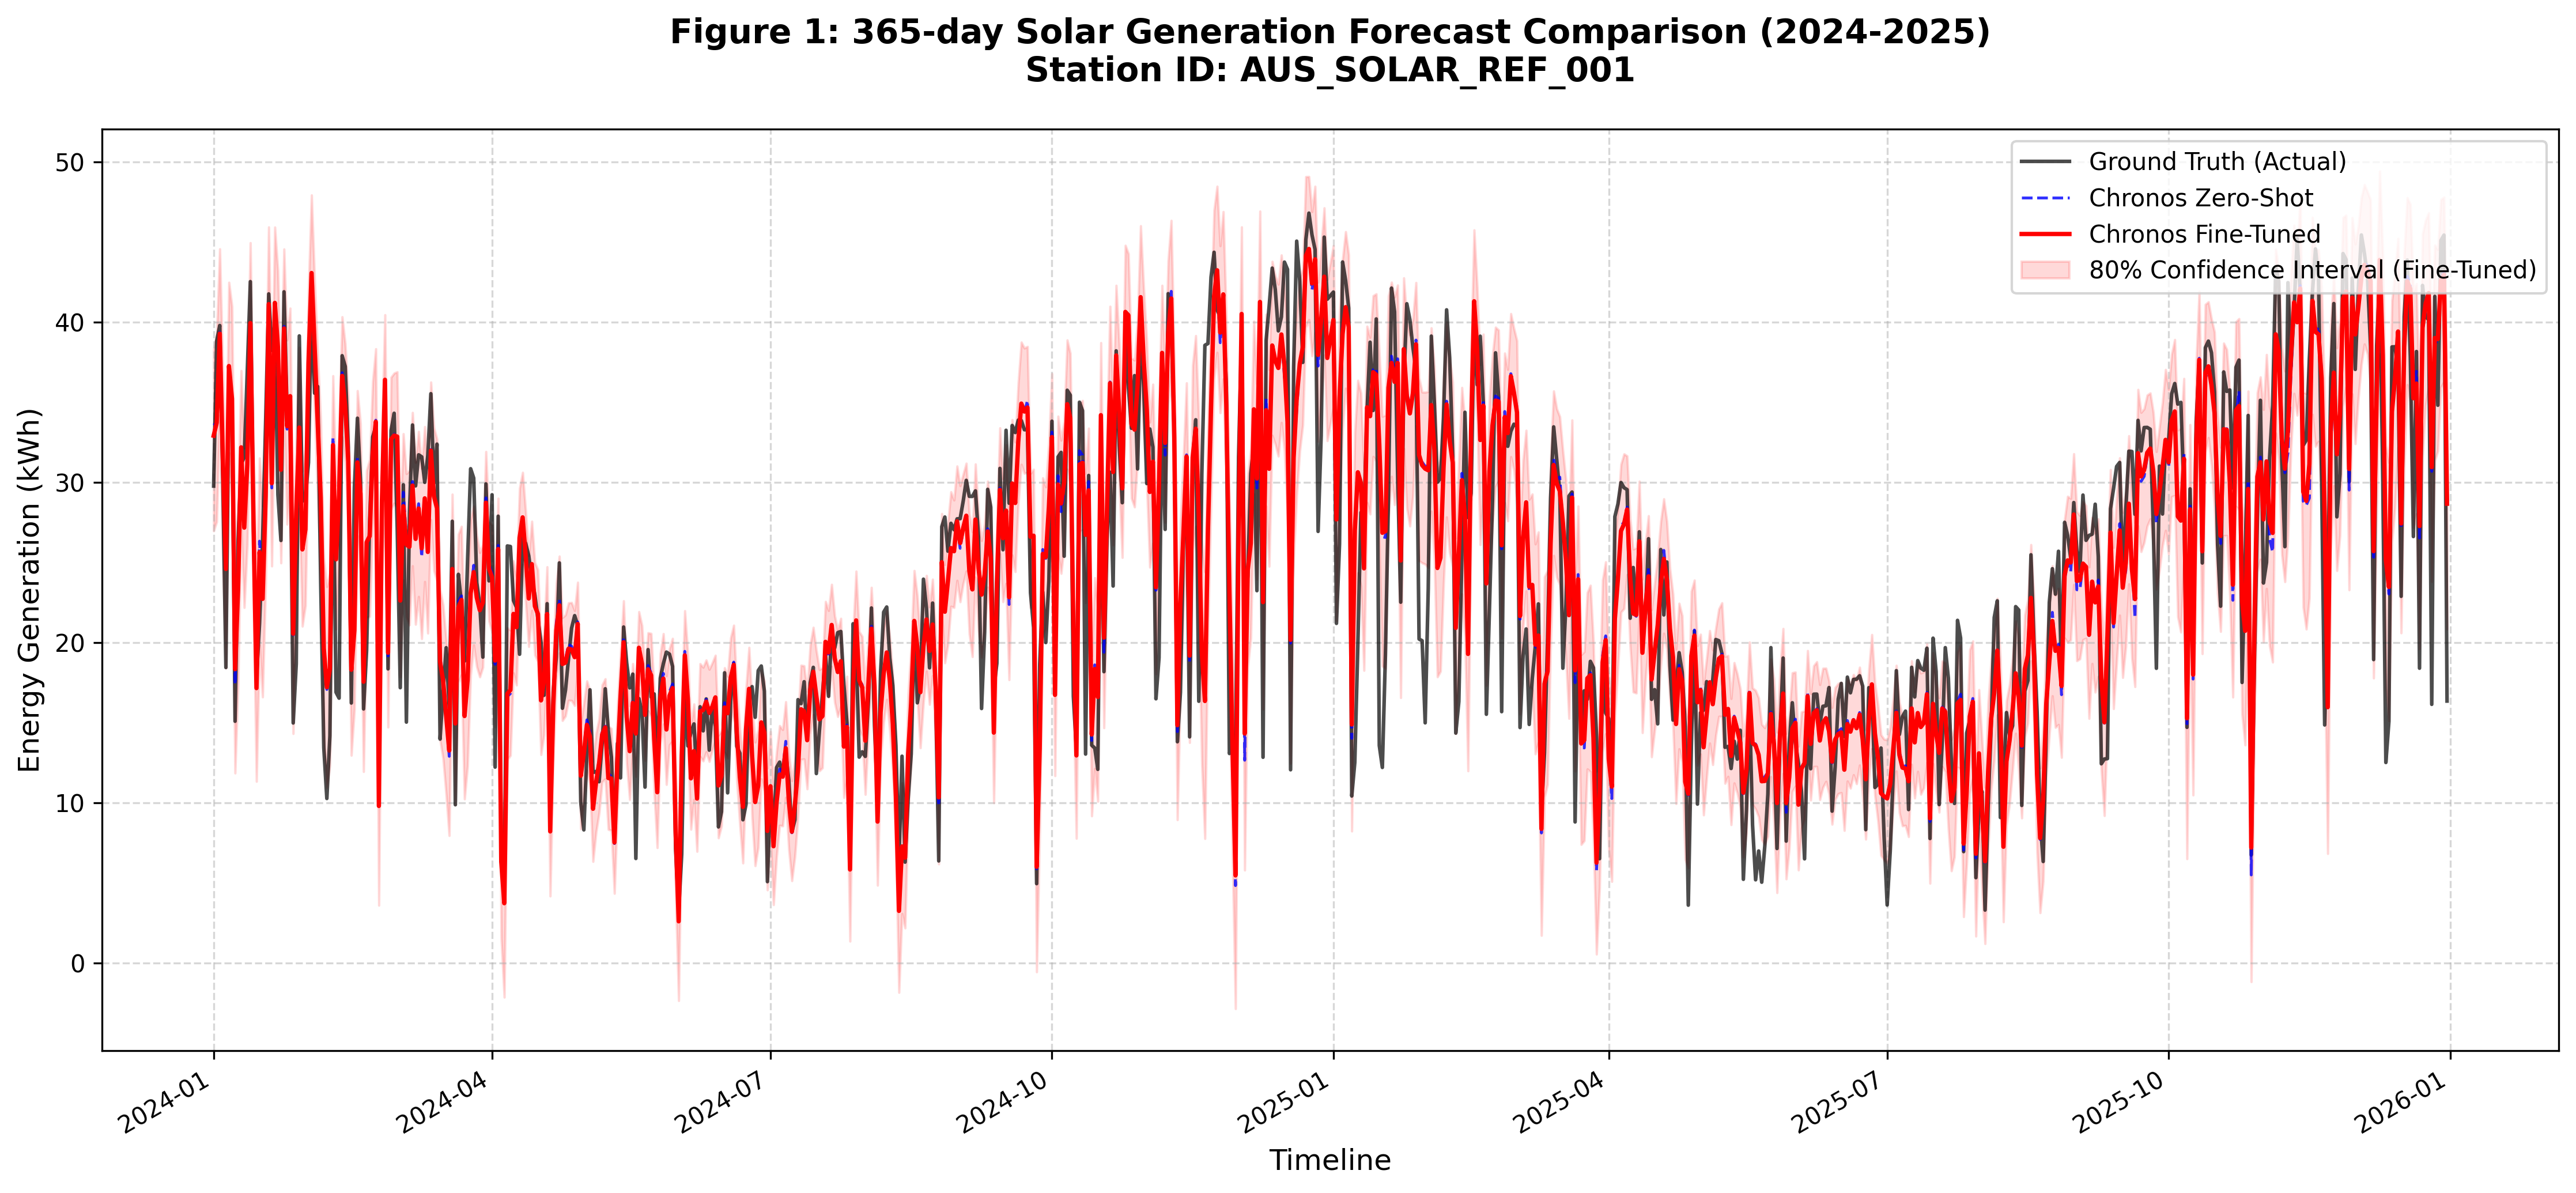

In [ ]:
import matplotlib.pyplot as plt

# 1. Chọn một trạm đại diện (Ví dụ trạm đầu tiên hoặc trạm bạn thấy đẹp)
target_station_id = "AUS_SOLAR_REF_001"

def plot_representative_figure(item_id, actual_df, forecast_dict):
    plt.figure(figsize=(15, 7), dpi=300)

    # Lấy dữ liệu thực tế của trạm đó
    # actual_df là test_data_combined, ta lấy item_id và lọc mốc thời gian khớp với dự báo
    y_true_all = actual_df.loc[item_id]

    # Lấy dự báo của 2 model từ storage
    df_zero = forecast_dict["Chronos Zero-Shot"].loc[item_id]
    df_fine = forecast_dict["Chronos Fine-Tuned"].loc[item_id]

    # Tìm index chung để vẽ cho khớp
    common_idx = y_true_all.index.intersection(df_fine.index)

    # Vẽ Ground Truth (Thực tế)
    plt.plot(common_idx, y_true_all.loc[common_idx, 'target'],
             label='Ground Truth (Actual)', color='black', linewidth=1.5, alpha=0.7)

    # Vẽ Zero-Shot (Đường đứt nét xanh)
    plt.plot(common_idx, df_zero.loc[common_idx, '0.5'],
             label='Chronos Zero-Shot', color='blue', linestyle='--', linewidth=1.2, alpha=0.8)

    # Vẽ Fine-Tuned (Đường đỏ đậm)
    plt.plot(common_idx, df_fine.loc[common_idx, '0.5'],
             label='Chronos Fine-Tuned', color='red', linewidth=1.8)

    # Vẽ Dải tin cậy 80% cho Fine-Tuned (vùng bóng mờ)
    plt.fill_between(common_idx,
                     df_fine.loc[common_idx, '0.1'],
                     df_fine.loc[common_idx, '0.9'],
                     color='red', alpha=0.15, label='80% Confidence Interval (Fine-Tuned)')

    # Định dạng biểu đồ chuyên nghiệp
    plt.title(f"Figure 1: 365-day Solar Generation Forecast Comparison (2024-2025)\nStation ID: {item_id}",
              fontsize=14, fontweight='bold', pad=20)
    plt.ylabel("Energy Generation (kWh)", fontsize=12)
    plt.xlabel("Timeline", fontsize=12)
    plt.legend(loc='upper right', frameon=True, fontsize=10)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)

    # Tối ưu hiển thị ngày tháng
    plt.gcf().autofmt_xdate()
    plt.tight_layout()

    # Lưu ảnh để chèn vào báo cáo
    plt.savefig("representative_forecast_comparison.png")
    plt.show()

# Gọi hàm vẽ
plot_representative_figure(target_station_id, test_data_combined, all_forecast_storage)

## **Push finetuned model to HF**

In [2]:
!pip install -q huggingface_hub

In [3]:
from google.colab import userdata
from huggingface_hub import HfApi, login
import os

HF_TOKEN = userdata.get("HF_TOKEN")

if HF_TOKEN is None:
    raise ValueError("HF_TOKEN not found. Please add HF_TOKEN in Colab Secrets.")

login(token=HF_TOKEN)

In [4]:
model_path = "/content/drive/MyDrive/TT/finetuned_model/chronos_2/weather_vars_6_1e_6_300_8"

repo_id = "codenhenhe/chronos2-volta-solar-daily"

api = HfApi()

api.create_repo(
    repo_id=repo_id,
    repo_type="model",
    private=False,
    exist_ok=True,
    token=HF_TOKEN
)

RepoUrl('https://huggingface.co/codenhenhe/chronos2-volta-solar-daily', endpoint='https://huggingface.co', repo_type='model', repo_id='codenhenhe/chronos2-volta-solar-daily')

In [5]:
readme_path = os.path.join(model_path, "README.md")

model_card = """---
license: apache-2.0
tags:
- time-series-forecasting
- solar-energy
- chronos
- autogluon
- lora
- australia
library_name: autogluon
base_model: amazon/chronos-2
datasets:
- codenhenhe/volta-solar-daily-v1
---

# Chronos-2 Fine-tuned for Australian Solar Generation Forecasting

This repository contains a fine-tuned Chronos-2 model for daily solar generation forecasting in Australia. The model was fine-tuned using AutoGluon TimeSeriesPredictor and saved as an AutoGluon predictor directory.

## Model Details

- Base model: `amazon/chronos-2`
- Framework: AutoGluon TimeSeriesPredictor
- Fine-tuning method: LoRA
- Forecasting task: Daily solar generation forecasting
- Prediction length: 365 days
- Context length: 730 days
- Target variable: Daily solar generation
- Evaluation metric during training: MSE

## Input Features

The model uses historical solar generation together with temporal and weather-related covariates.

Known covariates include:

- `day_of_year`
- `month`
- `ALLSKY_SFC_SW_DWN`
- `T2M`
- `WS2M`
- `RH2M`

## Initial Metrics

The following metrics were obtained from the initial evaluation after fine-tuning. The model was evaluated on the 2024 and 2025 test periods.

### Point Forecast Accuracy

| Model | Period | MAE | MSE | RMSE | sMAPE (%) | R2 |
|---|---:|---:|---:|---:|---:|---:|
| Chronos Fine-Tuned | 2024 | 2.374061 | 11.042445 | 3.323017 | 10.768443 | 0.889873 |
| Chronos Fine-Tuned | 2025 | 2.468275 | 12.076611 | 3.475142 | 11.053124 | 0.883387 |
| Chronos Fine-Tuned | Overall | 2.421168 | 11.559528 | 3.399931 | 10.910783 | 0.886614 |

### Probabilistic Metrics

| Model | Period | Q_0.1 | Q_0.9 | Avg_Q_Loss |
|---|---:|---:|---:|---:|
| Chronos Fine-Tuned | 2024 | 0.601763 | 0.500016 | 0.550889 |
| Chronos Fine-Tuned | 2025 | 0.635956 | 0.506356 | 0.571156 |
| Chronos Fine-Tuned | Overall | 0.618859 | 0.503186 | 0.561023 |

## Baseline Comparison

The fine-tuned model was also compared against a seasonal naive baseline.

| Model | MAE | RMSE | MAPE (%) | R2 |
|---|---:|---:|---:|---:|
| Chronos2-Volta AI | 2.600748 | 3.640213 | 12.897249 | 0.870021 |
| Seasonal Naive Baseline | 6.080324 | 8.468857 | 29.693408 | 0.296490 |

## Loading the Model

This model is stored as an AutoGluon TimeSeriesPredictor directory. After downloading the repository, it can be loaded as follows:

```python
from autogluon.timeseries import TimeSeriesPredictor

predictor = TimeSeriesPredictor.load("path_to_downloaded_model")
```

## Intended Use

This model is intended for postcode-based daily solar generation forecasting in Australia. It can be used as part of a pipeline that maps a user postcode to a representative solar reference point, retrieves or simulates weather covariates, and forecasts future solar generation.

## Limitations

The model depends on the quality of postcode mapping, weather covariates, and historical solar generation data. Forecast accuracy may vary across regions, seasons, and unusual weather conditions.
"""

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(model_card)

print(f"Model card saved to: {readme_path}")

Model card saved to: /content/drive/MyDrive/TT/finetuned_model/chronos_2/weather_vars_6_1e_6_300_8/README.md


In [6]:
api.upload_folder(
    folder_path=model_path,
    repo_id=repo_id,
    repo_type="model",
    token=HF_TOKEN,
    commit_message="Upload fine-tuned Chronos-2 model with model card and initial metrics"
)

print(f"Uploaded model to: https://huggingface.co/{repo_id}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ..._300_8/utils/data/val.pkl:   2%|1         |  897kB / 52.6MB            

  ..._6_1e_6_300_8/learner.pkl:  28%|##7       | 2.07kB / 7.43kB            

  ...adapter_model.safetensors:  28%|##7       | 2.63MB / 9.45MB            

...

  ...2_FineTuned/utils/oof.pkl:  28%|##7       | 2.24MB / 8.04MB            

  ...ronos2_ZeroShot/model.pkl:  28%|##7       |   346B / 1.25kB            

  ...s2_ZeroShot/utils/oof.pkl:  28%|##7       | 2.24MB / 8.04MB            

  ...ls/cached_predictions.pkl:  28%|##7       | 8.95MB / 32.2MB            

Uploaded model to: https://huggingface.co/codenhenhe/chronos2-volta-solar-daily


# **No Weather vars**

## **Finetuning**

In [ ]:
prediction_length = 365

known_covariate_names = ['day_of_year', 'month']

predictor = TimeSeriesPredictor(
    target='target',
    prediction_length=prediction_length,
    path="/content/drive/MyDrive/TT/finetuned_model/chronos_2/no_weather_vars/",
    eval_metric="MSE",
    known_covariates_names=known_covariate_names
)

In [ ]:
hyperparameters = {
    "Chronos2": [
        # 1. Bản Zero-shot (Chỉ dự báo, không học thêm)
        {"ag_args": {"name_suffix": "_ZeroShot"}},

        # 2. Bản Fine-tuned (Có học thêm với LoRA)
        {
            "fine_tune": True,
            "fine_tune_mode": "lora",
            "fine_tune_lr": 1e-4,
            "fine_tune_batch_size": 8,
            "fine_tune_steps": 500,
            "ag_args": {"name_suffix": "_FineTuned"}
        },
    ]
}

In [ ]:
predictor.fit(
    train_data=train_data_raw,
    tuning_data=tuning_data,
    hyperparameters=hyperparameters,
    time_limit=3600,
    enable_ensemble=False,
)

Beginning AutoGluon training... Time limit = 3600s
AutoGluon will save models to '/content/drive/MyDrive/TT/finetuned_model/chronos_2/no_weather_vars'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 11.82/14.56 GB
Total GPU Memory:   Free: 11.82 GB, Allocated: 2.74 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       7.55 GB / 12.67 GB (59.6%)
Disk Space Avail:   60.58 GB / 112.64 GB (53.8%)

Fitting with arguments:
{'enable_ensemble': False,
 'eval_metric': MSE,
 'hyperparameters': {'Chronos2': [{'ag_args': {'name_suffix': '_ZeroShot'}},
                                  {'ag_args': {'name_suffix': '_FineTuned'},
                                   'fine_tune': True,
                                   'fine_t

## **Evaluation**

In [ ]:
test_data_raw = prepare_data(test_df)

test_data_combined = pd.concat([train_data_raw, val_data_raw, test_data_raw])
test_data_combined = TimeSeriesDataFrame(test_data_combined).sort_values(["item_id", "timestamp"])

test_data_combined

ALLSKY_SFC_SW_DWN    T2M  WS2M   RH2M    T_cell  \
item_id           timestamp                                                     
AUS_SOLAR_REF_000 2016-01-01             8.9544  31.15  4.20  40.78  53.53600   
                  2016-01-02             8.5466  26.56  4.61  53.99  47.92650   
                  2016-01-03             8.2236  26.15  2.78  55.57  46.70900   
                  2016-01-04             5.6350  25.23  3.16  58.72  39.31750   
                  2016-01-05             5.3940  24.70  3.66  59.91  38.18500   
...                                         ...    ...   ...    ...       ...   
AUS_SOLAR_REF_499 2025-12-27             9.6631  19.30  2.33  41.20  43.45775   
                  2025-12-28             8.7079  21.64  3.20  37.60  43.40975   
                  2025-12-29             9.6110  24.35  1.99  34.56  48.37750   
                  2025-12-30             8.8459  27.43  1.90  27.50  49.54475   
                  2025-12-31             8.4458  28.13  3.41  25.73  49.24450   

                              temp_factor     target  day_of_year  month  
item_id           timestamp                                               
AUS_SOLAR_REF_000 2016-01-01     0.900124  42.557171            1      1  
                  2016-01-02     0.919757  41.505010            2      1  
                  2016-01-03     0.924018  40.121445            3      1  
                  2016-01-04     0.949889  28.261850            4      1  
                  2016-01-05     0.953852  27.166024            5      1  
...                                   ...        ...          ...    ...  
AUS_SOLAR_REF_499 2025-12-27     0.935398  47.725092          361     12  
                  2025-12-28     0.935566  43.015178          362     12  
                  2025-12-29     0.918179  46.593972          363     12  
                  2025-12-30     0.914093  42.693967          364     12  
                  2025-12-31     0.915144  40.809782          365     12  

[1826500 rows x 9 columns]

In [ ]:
# Đường dẫn đến thư mục model trên Google Drive của Linh
# model_path = '/content/drive/MyDrive/TT/finetuned_model/autogluon_chronos_lora_solar/'
model_path = '/content/drive/MyDrive/TT/finetuned_model/chronos_2/no_weather_vars/'

# Load mô hình
predictor_loaded = TimeSeriesPredictor.load(model_path)

# predictions = predictor_loaded.predict(past_data, known_covariates=known_covs)

Loading predictor from path /content/drive/MyDrive/TT/finetuned_model/chronos_2/no_weather_vars


In [ ]:
leaderboard = predictor_loaded.leaderboard(test_data_combined)
print(leaderboard)

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

                model  score_test  score_val  pred_time_test  pred_time_val  \
0  Chronos2_FineTuned  -35.334949 -35.498534      134.754103     107.316278   
1   Chronos2_ZeroShot  -36.192532 -35.761151      112.686501      81.702909   

   fit_time_marginal  fit_order  
0         277.779197          2  
1          19.545354          1  


In [ ]:
CONTEXT_LENGTH = 730
PREDICTION_LENGTH = 365
# Chronos2_ZeroShot

# 2025
context_2025 = test_data_combined.query("timestamp < '2025-01-01'").groupby('item_id').tail(CONTEXT_LENGTH)
known_2025 = test_data_combined.query("timestamp >= '2025-01-01' and timestamp < '2026-01-01'")[predictor_loaded.known_covariates_names]

forecast_2025 = predictor_loaded.predict(context_2025, known_covariates=known_2025, model="Chronos2_FineTuned")

# 2024
context_2024 = test_data_combined.query("timestamp < '2024-01-01'").groupby('item_id').tail(CONTEXT_LENGTH)
known_2024 = test_data_combined.query("timestamp >= '2024-01-01' and timestamp < '2025-01-01'")[predictor_loaded.known_covariates_names]

forecast_2024 = predictor_loaded.predict(context_2024, known_covariates=known_2024, model="Chronos2_FineTuned")

# Gộp kết quả dự báo 2 năm
all_forecasts = pd.concat([forecast_2024, forecast_2025])

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def calculate_metrics(y_true_df, y_pred_df, label):
    # Khớp index để tính toán
    common_idx = y_true_df.index.intersection(y_pred_df.index)
    y_true = y_true_df.loc[common_idx, 'target']
    y_pred = y_pred_df.loc[common_idx, '0.5']

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-5))) * 100 # +1e-5 để tránh chia cho 0 ban đêm

    print(f"--- Chỉ số cho {label} ---")
    print(f"MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | MAPE: {mape:.2f}%")
    return {"mse": mse, "rmse": rmse, "mae": mae, "mape": mape}

# Tính toán
metrics_2024 = calculate_metrics(test_data_combined, forecast_2024, "Năm 2024")
metrics_2025 = calculate_metrics(test_data_combined, forecast_2025, "Năm 2025")

--- Chỉ số cho Năm 2024 ---
MSE: 40.6305 | RMSE: 6.3742 | MAE: 4.4380 | MAPE: 25.01%
--- Chỉ số cho Năm 2025 ---
MSE: 37.8834 | RMSE: 6.1549 | MAE: 4.2795 | MAPE: 23.88%


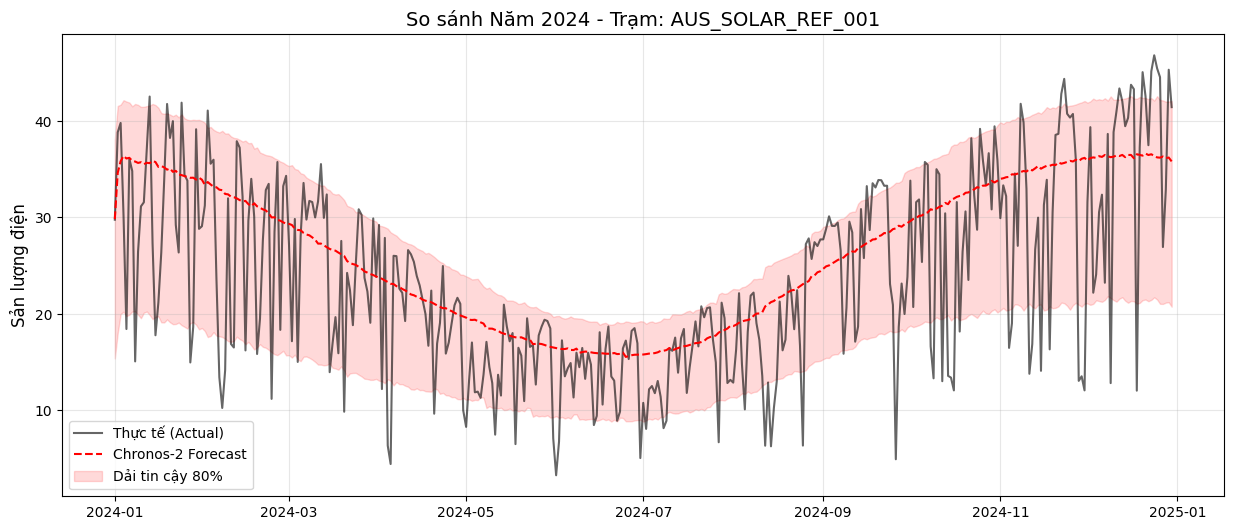

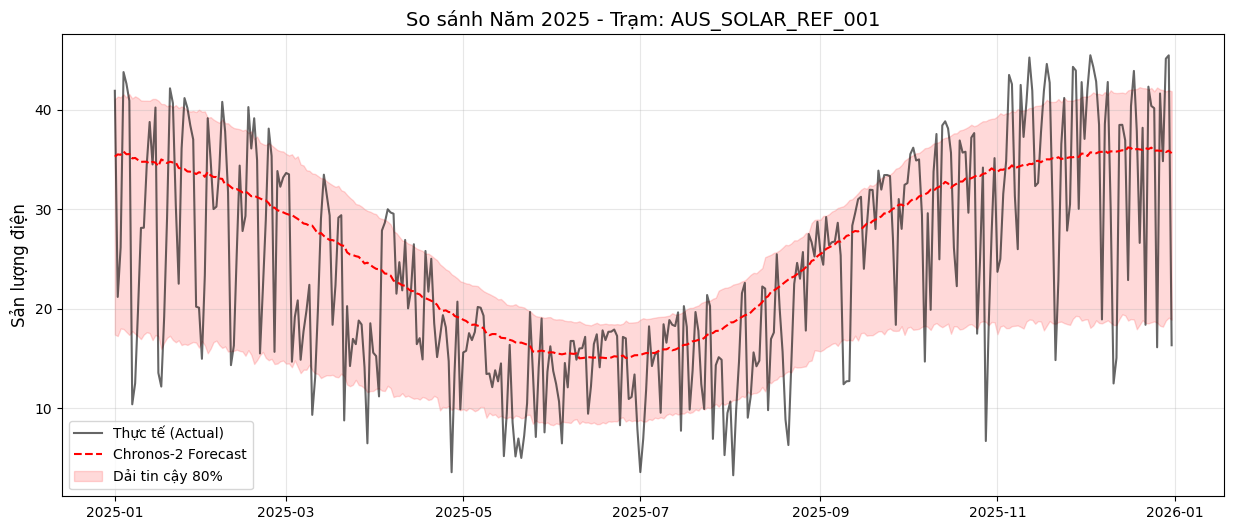

In [ ]:
import matplotlib.pyplot as plt

def plot_yearly_comparison(item_id, actual_df, forecast_df, title):
    plt.figure(figsize=(15, 6))

    # Lấy phần thực tế tương ứng với thời gian dự báo
    common_idx = actual_df.index.intersection(forecast_df.index)
    y_true = actual_df.loc[common_idx]
    y_pred = forecast_df.loc[common_idx]

    # Vẽ đường thực tế (Actual)
    plt.plot(y_true.index.get_level_values('timestamp'), y_true['target'],
             label='Thực tế (Actual)', color='black', alpha=0.6, linewidth=1.5)

    # Vẽ đường dự báo (Median - 0.5)
    plt.plot(y_pred.index.get_level_values('timestamp'), y_pred['0.5'],
             label='Chronos-2 Forecast', color='red', linestyle='--', linewidth=1.5)

    # Vẽ dải tin cậy 80% (giữa quantile 0.1 và 0.9)
    plt.fill_between(y_pred.index.get_level_values('timestamp'),
                     y_pred['0.1'], y_pred['0.9'],
                     color='red', alpha=0.15, label='Dải tin cậy 80%')

    plt.title(f"{title} - Trạm: {item_id}", fontsize=14)
    plt.ylabel("Sản lượng điện", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Chọn 1 trạm để kiểm tra
target_item = "AUS_SOLAR_REF_001"

# Vẽ cho năm 2024
plot_yearly_comparison(target_item, test_data_combined.loc[target_item],
                       forecast_2024.loc[target_item], "So sánh Năm 2024")

# Vẽ cho năm 2025
plot_yearly_comparison(target_item, test_data_combined.loc[target_item],
                       forecast_2025.loc[target_item], "So sánh Năm 2025")